Contexte 

Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

Partie 1 – Exploration du corpus 

1) Charger les données CSV ; 

In [2]:
import pandas as pd 

df = pd.read_csv('../data/smart_reviews_raw.csv')

2) Combien d'avis contient le dataset ? 

In [4]:
df.shape[0]

1200

3) Combien de colonnes possède-t-il ? 

In [5]:
df.shape[1]

8

4) Quel est le type de chaque colonne ?

In [7]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

5) Existe-t-il des valeurs manquantes ? 

In [9]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte 
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte 
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec 
répétition de caractères. 

In [11]:
import re
import pandas as pd

def identifier_types_texte(df, col="texte", n=1):
    """
    Affiche n exemple(s) de chaque type de texte particulier trouvé dans la colonne `col`.
    """
    pattern_url = r"http\S+|www\.\S+"

    pattern_mention = r"@\w+"

    pattern_hashtag = r"#\w+"
    
    pattern_emoji = (
        "[\U0001F300-\U0001FAFF"   # symboles/pictogrammes divers, emojis récents
        "\U00002700-\U000027BF"    # dingbats (✂, ✈, ❤...)
        "\U0001F600-\U0001F64F"    # émoticônes (😀-🙏)
        "\U0001F680-\U0001F6FF"    # transport et cartes
        "\u2600-\u26FF]"           # symboles divers (☀, ☂...)
    )

   
    pattern_ponctuation = r"[!?.]{2,}"

    pattern_repetition = r"(.)\1{2,}"


    textes = df[col]

    est_vide = textes.isna() | (textes.str.strip() == "")
    a_url = textes.str.contains(pattern_url, na=False, regex=True)
    a_mention = textes.str.contains(pattern_mention, na=False, regex=True)
    a_hashtag = textes.str.contains(pattern_hashtag, na=False, regex=True)
    a_emoji = textes.str.contains(pattern_emoji, na=False, regex=True)
    a_ponctuation = textes.str.contains(pattern_ponctuation, na=False, regex=True)
    est_majuscule = textes.str.isupper().fillna(False)
    a_repetition = textes.str.contains(pattern_repetition, na=False, regex=True)

    est_normal = (
        ~est_vide & ~a_url & ~a_mention & ~a_hashtag &
        ~a_emoji & ~a_ponctuation & ~est_majuscule & ~a_repetition
    )

    categories = {
        "Texte normal": est_normal,
        "Texte vide": est_vide,
        "Texte avec URL": a_url,
        "Texte avec mention": a_mention,
        "Texte avec hashtag": a_hashtag,
        "Texte avec emoji": a_emoji,
        "Texte avec ponctuation répétée": a_ponctuation,
        "Texte en majuscules": est_majuscule,
        "Texte avec répétition de caractères": a_repetition,
    }

    for nom_categorie, masque in categories.items():
        exemples = df.loc[masque, col].head(n)
        print(f"\n--- {nom_categorie} ({masque.sum()} occurrence(s) au total) ---")
        if exemples.empty:
            print("Aucun exemple trouvé.")
        else:
            for texte in exemples:
                print(repr(texte))


identifier_types_texte(df, col="texte", n=1)


--- Texte normal (342 occurrence(s) au total) ---
'Très  bonne  expérience,  simple  et  efficace.'

--- Texte vide (6 occurrence(s) au total) ---
nan

--- Texte avec URL (143 occurrence(s) au total) ---
'Produit parfait, rien à signaler. https://example.com/commande/17'

--- Texte avec mention (128 occurrence(s) au total) ---
'@client Livraison rapide et produit conforme à mes attentes.'

--- Texte avec hashtag (127 occurrence(s) au total) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec emoji (192 occurrence(s) au total) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec ponctuation répétée (141 occurrence(s) au total) ---
'Produit excellent, je suis très satisfait. !!!'

--- Texte en majuscules (146 occurrence(s) au total) ---
"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

--- Texte avec répétition de caractères (165 occurrence(s) au total) ---
'Produit excellent, je suis très satisfait. !!!'


C:\Users\rokha\AppData\Local\Temp\ipykernel_11980\51682347.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  a_repetition = textes.str.contains(pattern_repetition, na=False, regex=True)


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : 
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [12]:
df["longueur"] = df[col].fillna("").str.len()

print(f"Min : {df['longueur'].min()}")
print(f"Max : {df['longueur'].max()}")
print(f"Moyenne : {df['longueur'].mean():.1f}")
print(f"Médiane : {df['longueur'].median()}")
print(df["longueur"].quantile([0.25, 0.5, 0.75]))

Min : 0
Max : 636
Moyenne : 49.0
Médiane : 48.0
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

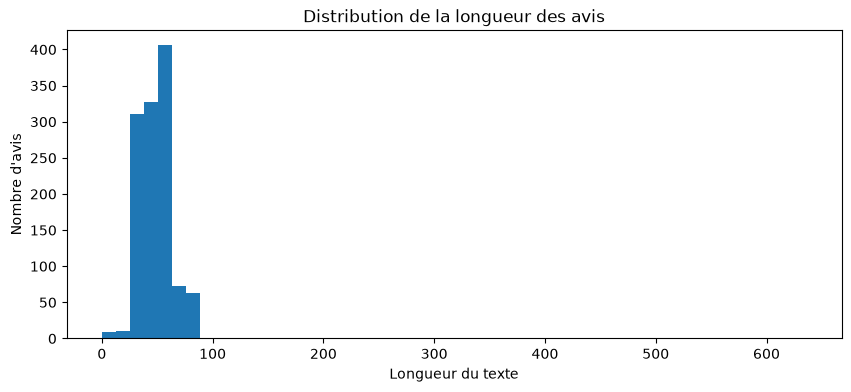

C:\Users\rokha\AppData\Local\Temp\ipykernel_11980\2056302895.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["longueur"], vert=False)


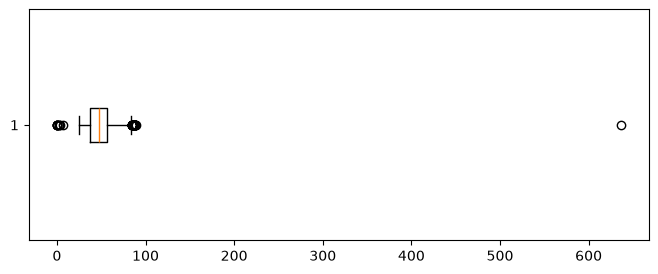

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(df["longueur"], bins=50)
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'avis")
plt.title("Distribution de la longueur des avis")
plt.show()

# boxplot pour repérer les outliers
plt.figure(figsize=(8, 3))
plt.boxplot(df["longueur"], vert=False)
plt.show()

a) Existe-t-il des textes anormalement longs ?

Oui. Le boxplot révèle un outlier net autour de 640 caractères, largement au-delà de la moustache supérieure (~90 caractères). Ce texte se distingue nettement du reste du corpus, où la quasi-totalité des avis se situe entre 0 et 100 caractères.

b) Existe-t-il beaucoup de textes très courts ? 

Non, pas de manière significative. Le boxplot et l'histogramme montrent seulement quelques observations proches de 0 caractère (quelques points isolés sous la moustache inférieure). La distribution est fortement concentrée entre 30 et 70 caractères, avec un pic autour de 50-60 caractères, ce qui indique que les textes très courts restent marginaux dans le dataset.

9) Détecter les textes vides 

In [17]:
textes_vides = df[df[col].isna() | (df[col].str.strip() == "")]
print(f"Nombre de textes vides : {len(textes_vides)}")

Nombre de textes vides : 6


10) Détecter les doublons sur le texte

In [19]:
doublons = df[df.duplicated(subset=[col], keep=False)]
print(f"Nombre de lignes en doublon : {len(doublons)}")
doublons.sort_values(col).head(10)

Nombre de lignes en doublon : 1036


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
312,AV0313,2026-04-18,mobile,Écouteurs AirSound,@client Excellent rapport qualité-prix.,positif,4,fr,39
419,AV0420,2026-04-11,sav,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1099,AV1100,2026-06-30,email,Tablette TabPlus,@client Excellent rapport qualité-prix.,positif,5,fr,39
45,AV0046,2026-08-26,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
466,AV0467,2026-07-04,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1059,AV1060,2026-01-24,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
146,AV0147,2026-08-11,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
593,AV0594,2026-06-11,mobile,SmartWatch Pro,@client Excellent rapport qualité-prix.,positif,4,fr,39
611,AV0612,2026-03-02,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
398,AV0399,2026-07-14,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39


11) Les classes sont-elles équilibrées ? 

In [22]:
print(df["sentiment"].value_counts())

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64


Non, les classes sont déséquilibrées. Sur un total de 1200 avis :

positif : 776 (64,7%)
neutre : 246 (20,5%)
negatif : 178 (14,8%)

La classe "positif" représente près des deux tiers du dataset, contre moins de 15% pour "negatif"

12) Quelle est la classe majoritaire ? 

positif, avec 776 avis (64,7% du dataset).